In [1]:
import torch
import matplotlib.pyplot as plt
from riemannian_geometry import RiemannianManifold, PullbackRiemannianManifold
from dataclasses import dataclass

In [2]:
@dataclass
class Sphere(PullbackRiemannianManifold):
    r: float

    def coordinate_map(self, coords: torch.Tensor) -> torch.Tensor:
        phi, theta = coords[..., 0], coords[..., 1]
        return torch.stack((
            self.r * torch.cos(theta) * torch.cos(phi),
            self.r * torch.cos(theta) * torch.sin(phi),
            self.r * torch.sin(theta),
        ), dim=-1)

M = Sphere(r=1.0)

In [7]:
source_geodesic = M.exponential_map(
    source=torch.tensor((0., 0.)),
    direction=torch.tensor((1., 0.2)),
    factor=10.0,
    resolution=32
)

Computing exponential map:  21%|██        | 66/320 [00:03<00:11, 21.58it/s]


_LinAlgError: torch.linalg.solve: The solver failed because the input matrix is singular.

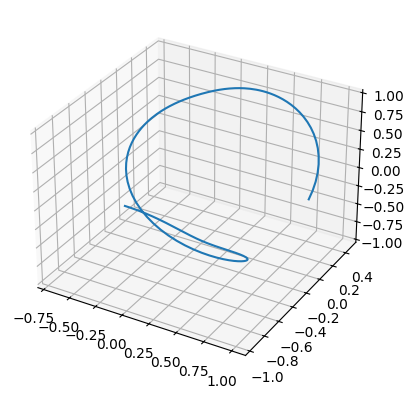

In [18]:
immersed_geodesic = M.coordinate_map(source_geodesic)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot(*immersed_geodesic.T)
plt.show()